# 05 — Final configuration selection and test evaluation

## Goal

Chạy local grid trên train, khóa đúng một cấu hình rồi đánh giá một lần trên test.

## Setup

Khởi tạo đường dẫn, module thuật toán và thư mục artifact.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / 'data' / 'DUC_TEXT').is_dir():
            PROJECT_ROOT = candidate
            break

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'textrank-parameter-analysis'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from experiment_utils import *

TRAIN_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'test'
REFERENCE_DIR = PROJECT_ROOT / 'data' / 'DUC_SUM'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'output' / 'textrank-parameter-analysis'
CSV_DIR = OUTPUT_DIR / 'csv'
CHART_DIR = OUTPUT_DIR / 'charts'
CSV_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project: {PROJECT_ROOT}')
print(f'Output : {OUTPUT_DIR}')

Project: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice
Output : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/textrank-parameter-analysis


## Steps

### 1. Build local candidate grid from train analyses

In [2]:
threshold_ranked = rank_configurations(read_csv(CSV_DIR / '02-threshold-summary.csv'), 50)
pagerank_ranked = rank_configurations(read_csv(CSV_DIR / '03-pagerank-summary.csv'), 50)
mmr_ranked = rank_configurations(read_csv(CSV_DIR / '04-mmr-summary.csv'), 50)

thresholds = [float(value) for value in top_unique_values(threshold_ranked, 'similarity_threshold', 3)]
pagerank_candidates = [(float(row['pagerank_damping']), float(row['pagerank_tolerance']),
                        int(float(row['pagerank_max_iterations']))) for row in pagerank_ranked[:2]]
mmr_candidates = []
for row in mmr_ranked:
    enabled = str(row['use_mmr']).lower() == 'true'
    candidate = (enabled, float(row['mmr_lambda']) if enabled else 0.0)
    if candidate not in mmr_candidates:
        mmr_candidates.append(candidate)
    if len(mmr_candidates) == 4:
        break
local_configs = build_local_grid(thresholds, pagerank_candidates, mmr_candidates)
print(f'Local grid: {len(local_configs)} unique configurations')

Local grid: 24 unique configurations


### 2. Select and lock one configuration on train

In [3]:
local_details, local_summaries = run_sweep(TRAIN_DIR, REFERENCE_DIR, local_configs, 'train')
ranked_train = rank_configurations(local_summaries, required_topics=50)
assert ranked_train, 'No configuration converged on every train topic'
recommended_train_row = ranked_train[0]
recommended_config = config_from_row(recommended_train_row)
write_csv(CSV_DIR / '05-local-grid-summary.csv', ranked_train, SUMMARY_FIELDS)
write_csv(CSV_DIR / '05-final-train-topic-metrics.csv',
          [row for row in local_details if row['config_id'] == recommended_train_row['config_id']], DETAIL_FIELDS)
print('Locked config:', config_id(recommended_config))

Locked config: t=0.02|d=0.85|tol=1e-08|iter=300|words=100|mmr=0.70


### 3. Evaluate the locked configuration once on test

In [4]:
test_rows = evaluate_config(TEST_DIR, REFERENCE_DIR, recommended_config, 'test')
for row in test_rows:
    row['config_id'] = config_id(recommended_config)
test_summary = aggregate_rows(test_rows)
write_csv(CSV_DIR / '05-final-test-topic-metrics.csv', test_rows, DETAIL_FIELDS)
recommendation = {
    'selection_rule': ['macro_precision_desc', 'macro_f1_desc',
                       'mean_redundancy_asc', 'mean_runtime_seconds_asc'],
    'tested_local_configurations': len(local_configs),
    'config': config_fields(recommended_config),
    'config_id': config_id(recommended_config),
    'train': {key: value for key, value in recommended_train_row.items()
              if key.startswith('macro_') or key.startswith('mean_') or key in ('eligible_topics', 'converged_topics')},
    'test': test_summary,
    'limitation': 'Exact (docid, num) match does not measure paraphrase or semantic equivalence.',
}
write_json(OUTPUT_DIR / '05-recommended-config.json', recommendation)
print('Test evaluation completed after configuration lock.')

Test evaluation completed after configuration lock.


### 4. Compare top configurations and train/test

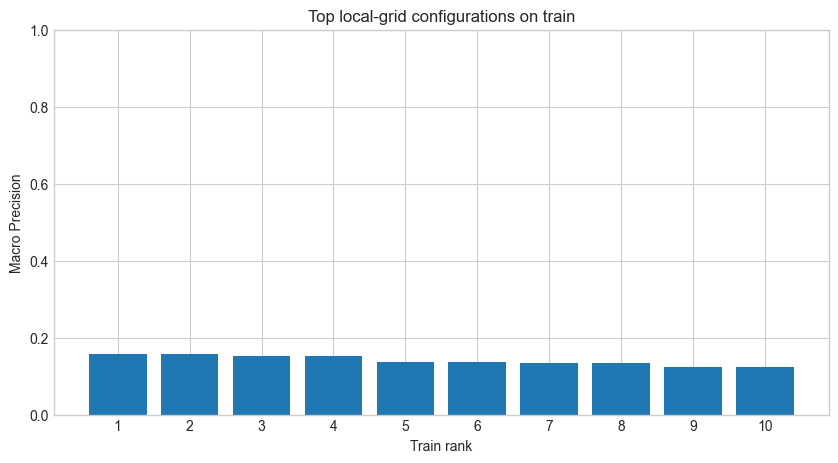

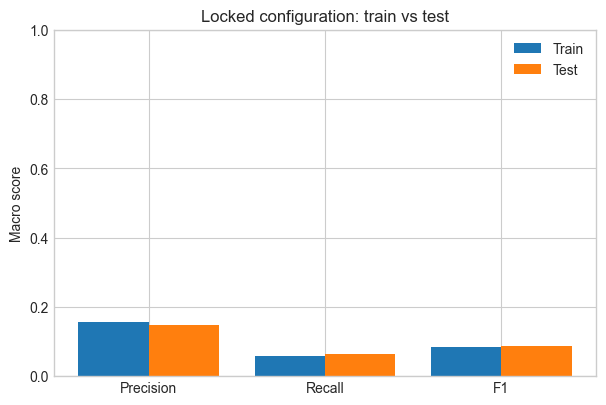

In [5]:
top = ranked_train[:10]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(row['rank']) for row in top], [row['macro_precision'] for row in top])
ax.set(title='Top local-grid configurations on train', xlabel='Train rank', ylabel='Macro Precision', ylim=(0, 1))
fig.savefig(CHART_DIR / '05-top-configurations.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ['Precision', 'Recall', 'F1']
train_values = [recommended_train_row['macro_precision'], recommended_train_row['macro_recall'], recommended_train_row['macro_f1']]
test_values = [test_summary['macro_precision'], test_summary['macro_recall'], test_summary['macro_f1']]
x = range(len(labels))
ax.bar([value - .2 for value in x], train_values, width=.4, label='Train')
ax.bar([value + .2 for value in x], test_values, width=.4, label='Test')
ax.set_xticks(list(x), labels)
ax.set(title='Locked configuration: train vs test', ylabel='Macro score', ylim=(0, 1))
ax.legend()
fig.savefig(CHART_DIR / '05-train-vs-test.png', dpi=160, bbox_inches='tight')
plt.show()

## Checks

Các assertion dưới đây bảo đảm artifact và dữ liệu của notebook đầy đủ.

In [6]:
assert len({row['topic'] for row in local_details
            if row['config_id'] == recommended_train_row['config_id']}) == 50
assert len({row['topic'] for row in test_rows}) == 9
for path in [CSV_DIR / '05-local-grid-summary.csv', CSV_DIR / '05-final-train-topic-metrics.csv',
             CSV_DIR / '05-final-test-topic-metrics.csv', CHART_DIR / '05-top-configurations.png',
             CHART_DIR / '05-train-vs-test.png', OUTPUT_DIR / '05-recommended-config.json']:
    assert path.is_file() and path.stat().st_size > 0, path
print('Final train/test separation and artifact checks passed.')

Final train/test separation and artifact checks passed.


## Takeaways

In [7]:
train_precision = float(recommended_train_row['macro_precision'])
test_precision = float(test_summary['macro_precision'])
print('Recommended config:', config_fields(recommended_config))
print(f'Train Precision={train_precision:.4f}, F1={float(recommended_train_row["macro_f1"]):.4f}')
print(f'Test  Precision={test_precision:.4f}, F1={float(test_summary["macro_f1"]):.4f}')
print(f'Precision train-test gap={train_precision - test_precision:+.4f}')
print('Conclusion applies only to the tested grid and exact sentence matching.')

Recommended config: {'similarity_threshold': 0.02, 'pagerank_damping': 0.85, 'pagerank_tolerance': 1e-08, 'pagerank_max_iterations': 300, 'max_summary_words': 100, 'use_mmr': True, 'mmr_lambda': 0.7}
Train Precision=0.1575, F1=0.0828
Test  Precision=0.1481, F1=0.0866
Precision train-test gap=+0.0093
Conclusion applies only to the tested grid and exact sentence matching.
